# Working withGgeohash in Vgrid DGGS

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeoshub/vgrid/blob/main/docs/notebooks/12_geohash.ipynb)
[![image](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/opengeoshub/vgrid/HEAD?filepath=docs/notebooks/12_geohash.ipynb)
[![image](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/opengeoshub/vgrid/blob/main/docs/notebooks/12_geohash.ipynb)
[![image](https://jupyterlite.rtfd.io/en/latest/_static/badge.svg)](https://jupyterlite.gishub.vn/lab/index.html?path=notebooks/vgrid/12_geohash.ipynb)

Full Vgrid DGGS documentation is available at [vgrid document](https://vgrid.gishub.vn).

To work with Vgrid DGGS directly in GeoPandas and Pandas, please use [vgridpandas](https://pypi.org/project/vgridpandas/). Full Vgridpandas DGGS documentation is available at [vgridpandas document](https://vgridpandas.gishub.vn).

To work with Vgrid DGGS in QGIS, install the [Vgrid Plugin](https://plugins.qgis.org/plugins/vgridtools/).

To visualize DGGS in Maplibre GL JS, try the [vgrid-maplibre](https://www.npmjs.com/package/vgrid-maplibre) library.

For an interactive demo, visit the [Vgrid Homepage](https://vgrid.vn).

### Install vgrid
Uncomment the following line to install [vgrid](https://pypi.org/project/vgrid/).

In [1]:
# %pip install vgrid --upgrade

### latlon2geohash

In [2]:
from vgrid.conversion.latlon2dggs import latlon2geohash

lat = 10.775276
lon = 106.706797
res = 6
geohash_id = latlon2geohash(lat, lon, res)
geohash_id

'w3gvk1'

### Geohash to Polygon

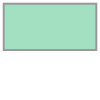

In [3]:
from vgrid.conversion.dggs2geo.geohash2geo import geohash2geo

geohash_geo = geohash2geo(geohash_id)
geohash_geo

### Geohash to GeoJSON        

In [ ]:
from vgrid.conversion.dggs2geo.geohash2geo import geohash2geojson

geohash_geojson = geohash2geojson(geohash_id)
# geohash_geojson

### Vector to Geohash

#### Multi(Point) to Geohash

Processing features: 100%|██████████| 12/12 [00:00<00:00, 5673.73it/s]


<Axes: >

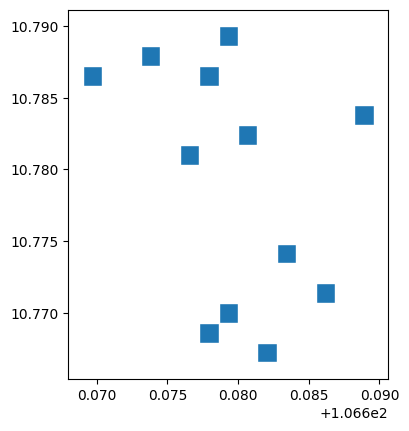

In [10]:
from vgrid.conversion.vector2dggs.vector2geohash import vector2geohash

file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/point.geojson"
)
point_to_geohash = vector2geohash(
    file_path,
    # resolution=7,
    topology=True,
    output_format="gpd", verbose=True,
)
point_to_geohash.plot(edgecolor="white")

#### Multi(Polygon) to Geohash

Processing features: 100%|██████████| 1/1 [00:00<00:00, 11.76it/s]


<Axes: >

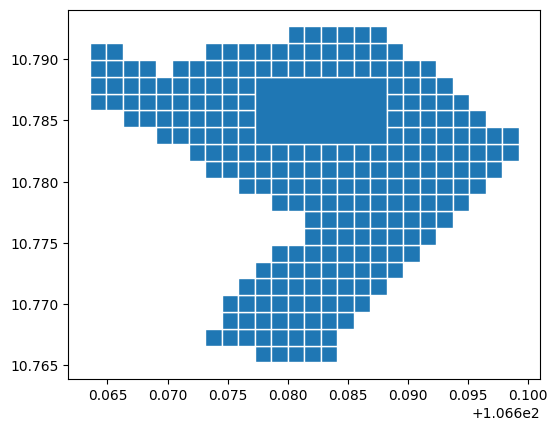

In [1]:
from vgrid.conversion.vector2dggs.vector2geohash import vector2geohash

file_path = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polygon2.geojson"
vector_to_geohash = vector2geohash(
    file_path,
    resolution=7,
    compact=True,
    depth=-1,  # used when compact=True; -1: full compact
    predicate="intersects",
    output_format="gpd", verbose=True,
)
# Visualize the output
vector_to_geohash.plot(edgecolor="white")

### Geohash Compact

<Axes: >

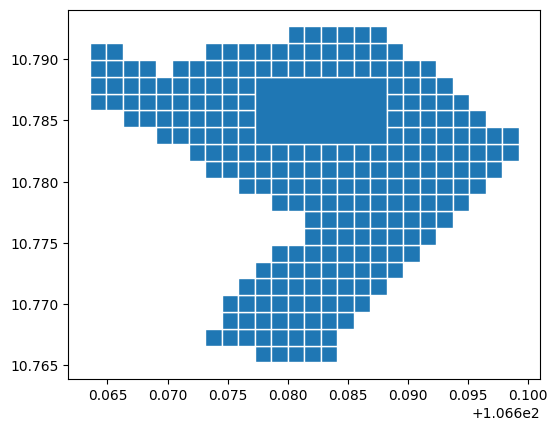

In [2]:
from vgrid.conversion.dggscompact.geohashcompact import geohashcompact

geohash_compacted = geohashcompact(
    vector_to_geohash, geohash_id="geohash", depth=-1, output_format="gpd", verbose=True
)
geohash_compacted.plot(edgecolor="white")

### Geohash Expand

<Axes: >

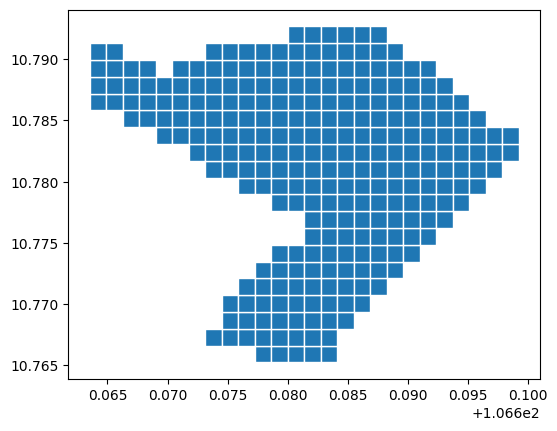

In [3]:
from vgrid.conversion.dggscompact.geohashcompact import geohashexpand

geohash_expanded = geohashexpand(vector_to_geohash, resolution=7,  # if set, depth is ignored
    # depth=1,  # 1: children
    output_format="gpd", verbose=True)
geohash_expanded.plot(edgecolor="white")

### Geohash Binning

Generating Geohash DGGS: 100%|██████████| 1566/1566 [00:00<00:00, 1981.39 cells/s]


<Axes: >

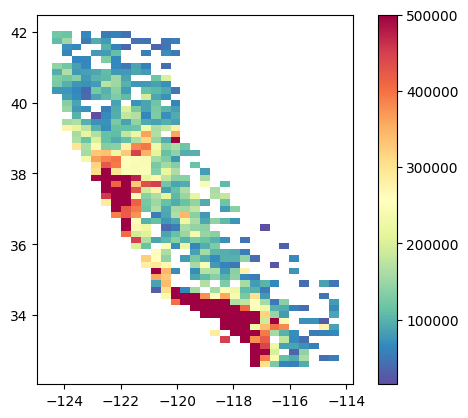

In [2]:
from vgrid.binning.geohashbin import geohashbin

file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/csv/housing.csv"
)
agg = "max"
numeric_col = "median_house_value"

geohash_bin = geohashbin(
    file_path,
    resolution=4,
    agg=agg,
    numeric_col=numeric_col,
    # category_col="category",
    output_format="gpd", verbose=True,
)
geohash_bin.plot(
    column=f"{numeric_col}_{agg}",  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### Geohash Resampling

Generating A5 cells: 100%|██████████| 1947/1947 [00:00<00:00, 6074.69 cells/s]


<Axes: >

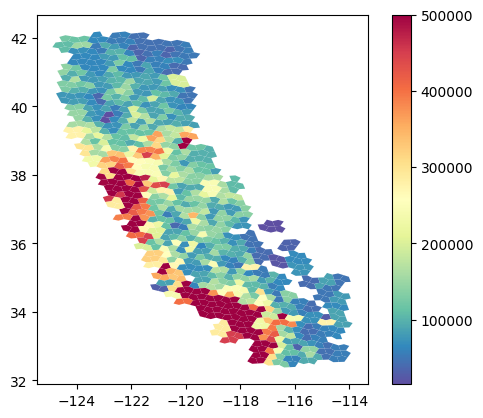

In [ ]:
from vgrid.conversion.dggsresample import dggsresample

geohash_resample = dggsresample(
    source_dggs=geohash_bin,
    dggs_from="geohash",
    dggs_to="a5",
    method="nearest",  # area_weighted, nearest
    predicate="centroid_within",  # centroid_within, intersects
    dggs_col="geohash",
    resample_col=f"{numeric_col}_{agg}",  # column on h3_bin with numbers
    fix_antimeridian=None,
    split_antimeridian=False,
    verbose=True,
)
geohash_resample.plot(
    column=f"{numeric_col}_{agg}",  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### Raster to Geohash

#### Download and open raster

rgb.tif already exists. Skip downloading. Set overwrite=True to overwrite.
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 240, 'height': 147, 'count': 3, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(2.6640125000199077e-06, 0.0, 106.708118755,
       0.0, -2.6640136054383103e-06, 10.812568272)}


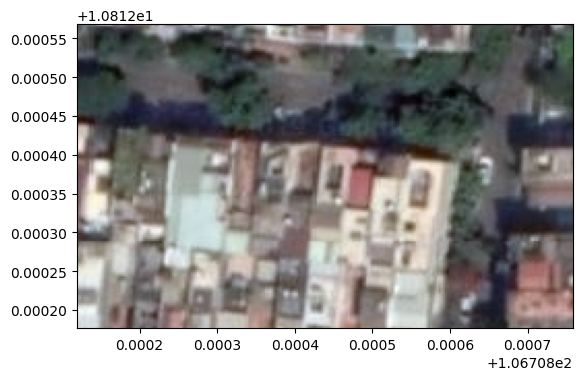

<Axes: >

In [4]:
from vgrid.utils.io import download_file
import rasterio
from rasterio.plot import show

raster_url = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/raster/rgb.tif"
)
raster_file = download_file(raster_url)
src = rasterio.open(raster_file, "r")
print(src.meta)
show(src)

#### Convert raster to Geohash

In [10]:
# %pip install folium

In [5]:
from vgrid.conversion.raster2dggs.raster2geohash import raster2geohash

raster_to_geohash = raster2geohash(
    raster_file,
    method="nearest",  # nearest, binning
    stats="mean",
    output_format="gpd", verbose=True,
)

# Visualize the output
import folium

m = folium.Map(tiles="CartoDB positron", max_zoom=28)

geohash_layer = folium.GeoJson(
    raster_to_geohash,
    style_function=lambda x: {
        "fillColor": f"rgb({x['properties']['band_1']}, {x['properties']['band_2']}, {x['properties']['band_3']})",
        "fillOpacity": 1,
        "color": "black",
        "weight": 1,
    },
    popup=folium.GeoJsonPopup(
        fields=["geohash", "band_1", "band_2", "band_3"],
        aliases=["Geohash ID", "Band 1", "Band 2", "Band 3"],
        style="""
            background-color: white;
            border: 2px solid black;
            border-radius: 3px;
            box-shadow: 3px;
        """,
    ),
).add_to(m)

m.fit_bounds(geohash_layer.get_bounds())

# Display the map
m

Cell size: 0.08638527081938627 m2
Nearest Geohash resolution determined: 10
Method: nearest_neighbour


Reading raster pixel centers: 100%|██████████| 14/14 [00:02<00:00,  4.99 block/s]


### Geohash Generator

Generating Geohash DGGS: 100%|██████████| 118/118 [00:00<00:00, 9822.92 cells/s]


<Axes: >

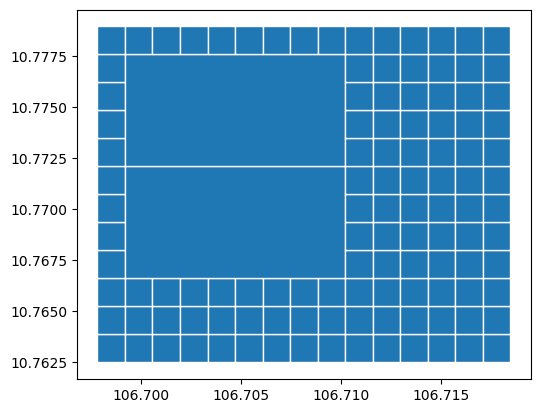

In [1]:
from vgrid.generator.geohashgrid import geohashgrid

# geohash_grid = geohashgrid(resolution=1,output_format="gpd")
geohash_grid = geohashgrid(
    resolution=7,
    bbox=[106.699007, 10.762811, 106.717674, 10.778649],
    compact=True,
    output_format="gpd", verbose=True,
)
geohash_grid.plot(edgecolor="white")

### Geohash Inspect

In [5]:
from vgrid.stats.geohashstats import geohashinspect

resolution = 3
geohash_inspect = geohashinspect(resolution, verbose=True)
geohash_inspect.head()

Generating Geohash DGGS: 100%|██████████| 32768/32768 [00:01<00:00, 21401.75 cells/s]


,geohash,resolution,center_lat,center_lon,cell_width,cell_height,cell_area,cell_perimeter,geometry,crossed,norm_area,ipq,zsc,cvh
0,d85,3,0.703125,-62.578125,156543.033928,155495.388866,2.434052e+10,624030.010870,"POLYGON ((-63.28125 0, -61.875 0, -61.875 1.40...",False,1.563701,0.785469,0.886246,1.0
1,073,3,-71.015625,-166.640625,49252.440994,156901.708305,8.013363e+09,415949.629204,"POLYGON ((-167.34375 -71.71875, -165.9375 -71....",False,0.514800,0.582027,0.762901,1.0
2,pcw,3,-80.859375,177.890625,23044.667706,157029.520704,3.917353e+09,363953.336031,"POLYGON ((177.1875 -81.5625, 178.59375 -81.562...",False,0.251661,0.371630,0.609613,1.0
3,hp5,3,-49.921875,4.921875,99507.584180,156413.740426,1.579450e+10,514780.049597,"POLYGON ((4.21875 -50.625, 5.625 -50.625, 5.62...",False,1.014682,0.748984,0.865425,1.0
4,vg6,3,63.984375,82.265625,70570.827696,156764.626284,1.079198e+10,451213.306310,"POLYGON ((81.5625 63.28125, 82.96875 63.28125,...",False,0.693306,0.666112,0.816148,1.0


### Geohash Normalized Area Histogram

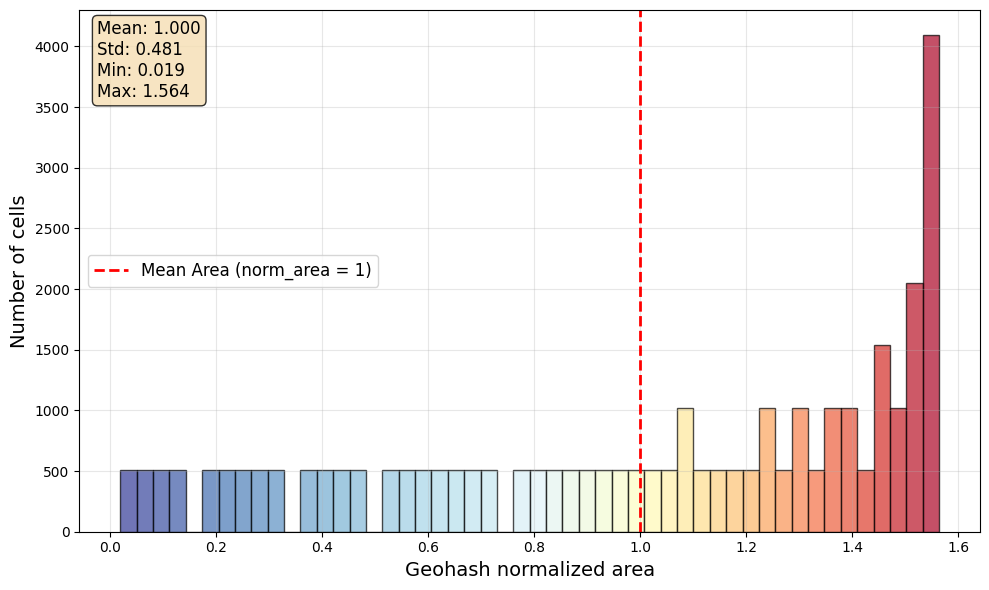

In [6]:
from vgrid.stats.geohashstats import geohash_norm_area_hist

geohash_norm_area_hist(geohash_inspect)

### Distribution of Geohash Area Distortions

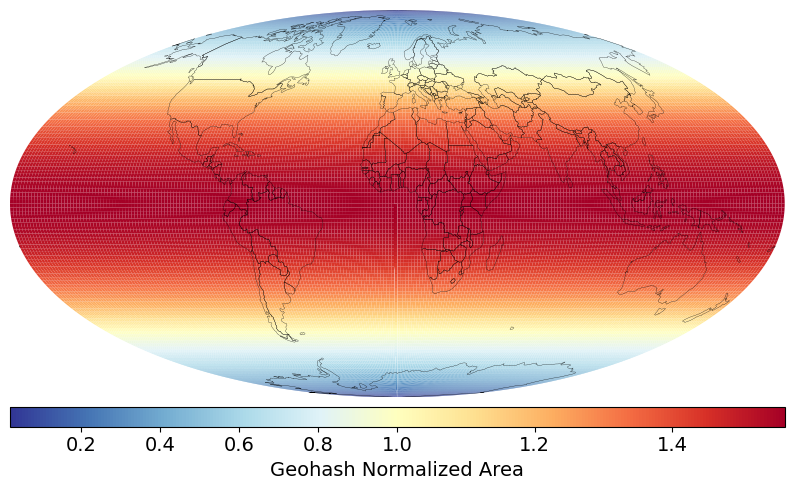

In [7]:
from vgrid.stats.geohashstats import geohash_norm_area

geohash_norm_area(geohash_inspect)

### Geohash IPQ Compactness Histogram

Isoperimetric Inequality (IPQ) Compactness (suggested by [Osserman, 1978](https://sites.math.washington.edu/~toro/Courses/20-21/MSF/osserman.pdf)):

$$C_{IPQ} = \frac{4 \pi A}{p^2}$$
The range of the IPQ compactness metric is (0,1]. 

A circle represents the maximum compactness with a value of 1. 

As shapes become more irregular or elongated, their compactness decreases toward 0.

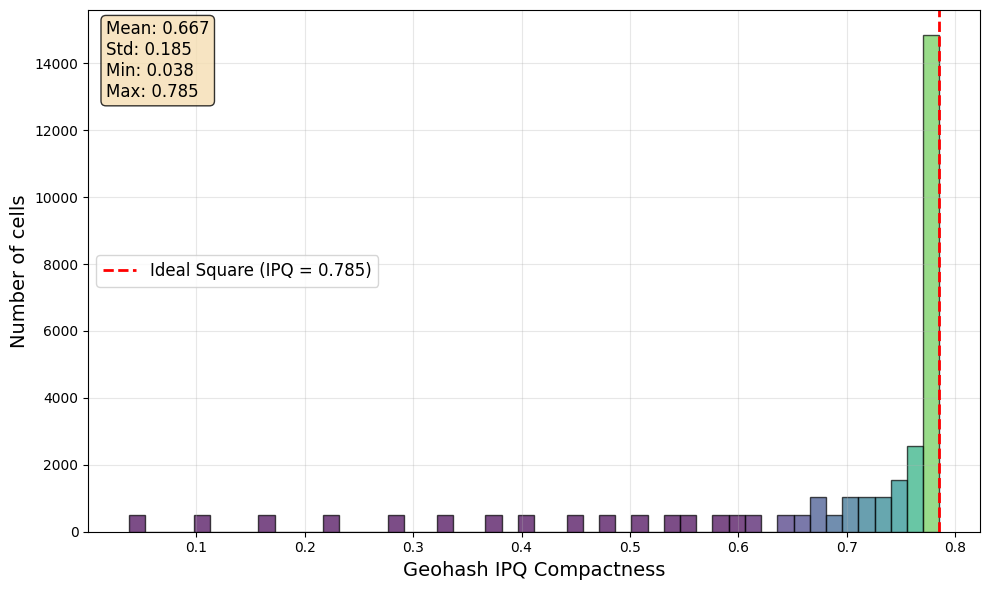

In [8]:
from vgrid.stats.geohashstats import geohash_compactness_ipq_hist

geohash_compactness_ipq_hist(geohash_inspect)

### Distribution of Geohash IPQ Compactness

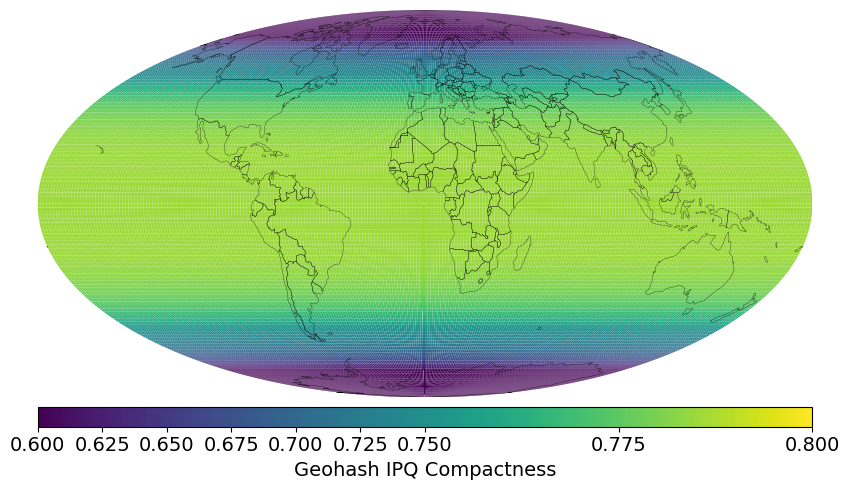

In [9]:
from vgrid.stats.geohashstats import geohash_compactness_ipq

geohash_compactness_ipq(geohash_inspect)

### Geohash Convex hull Compactness Histogram:

$$C_{CVH} = \frac{A}{A_{CVH}}$$


The range of the convex hull compactness metric is (0,1]. 

As shapes become more concave, their convex hull compactness decreases toward 0.

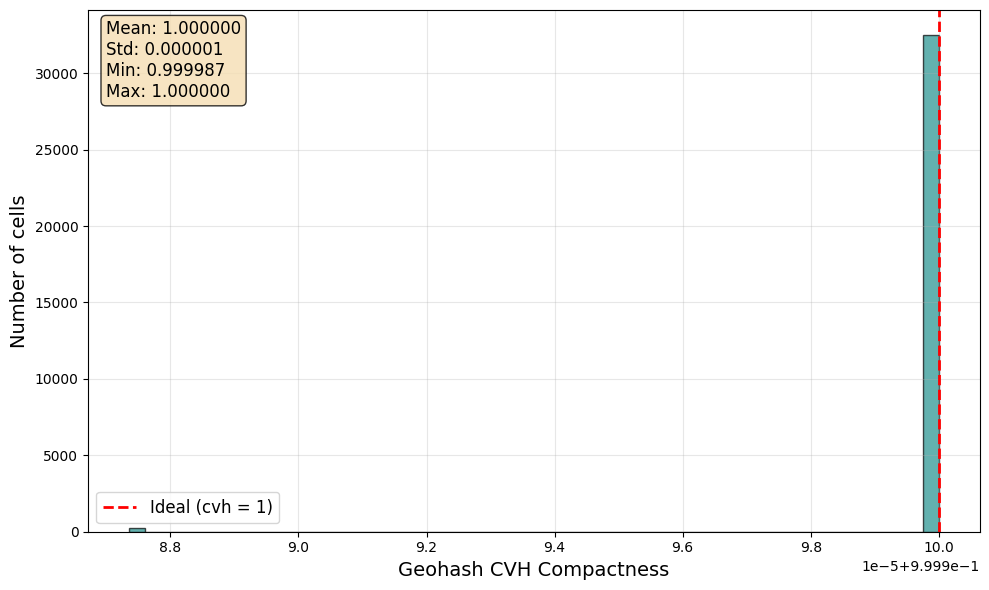

In [10]:
from vgrid.stats.geohashstats import geohash_compactness_cvh_hist

geohash_compactness_cvh_hist(geohash_inspect)

### Distribution of Geohash Convex hull Compactness

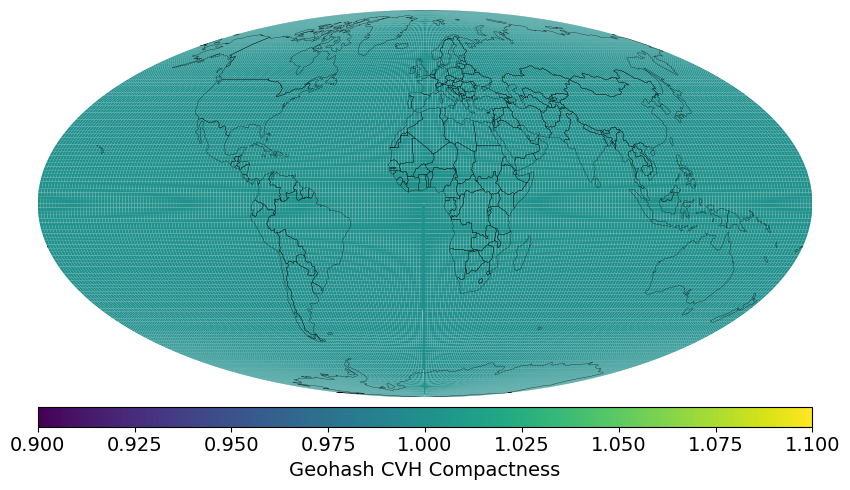

In [11]:
from vgrid.stats.geohashstats import geohash_compactness_cvh

geohash_compactness_cvh(geohash_inspect)

### Geohash Statistics

Characteristic Length Scale (CLS - suggested by Ralph Kahn): the diameter of a spherical cap of the same cell's area

In [1]:
from vgrid.stats import geohashstats

geohashstats()

,resolution,number_of_cells,avg_edge_len_m,avg_cell_area_m2,cls_m
0,1,32,3.992437e+06,1.593955e+13,4.528782e+06
1,2,1024,7.057698e+05,4.981110e+11,7.965056e+05
2,3,32768,1.247636e+05,1.556597e+10,1.407814e+05
3,4,1048576,2.205531e+04,4.864365e+08,2.488675e+04
4,5,33554432,3.898864e+03,1.520114e+07,4.399397e+03
5,6,1073741824,6.892283e+02,4.750356e+05,7.777108e+02
6,7,34359738368,1.218395e+02,1.484486e+04,1.374812e+02
7,8,1099511627776,2.153838e+01,4.639020e+02,2.430346e+01
8,9,35184372088832,3.807484e+00,1.449694e+01,4.296286e+00
9,10,1125899906842624,6.730745e-01,4.530293e-01,7.594832e-01
